# LightGBM con preprocesamiento EEG v2 — Jhoan Saavedra

Este experimento conserva exclusivamente `EEG Fpz-Cz` y `EEG Pz-Oz`. Compara un flujo mejorado para N1: dinámica espectral en subventanas de 5 segundos, calidad de señal, contexto móvil corto y diferencias temporales explícitas.

## 1. Configuración

In [1]:
from pathlib import Path
import sys
import pandas as pd

REPO_ROOT = next(
    path for path in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
    if (path / 'data.dvc').is_file()
)
PACKAGE_SRC = REPO_ROOT / 'packages' / 'sleep-staging' / 'src'
if str(PACKAGE_SRC) not in sys.path:
    sys.path.insert(0, str(PACKAGE_SRC))

from IPython.display import display
from sleep_staging import PreprocessingConfig, PreprocessingPipeline
from sleep_staging.datasets import discover_sleep_telemetry_records
from sleep_staging.training import (
    MlflowConfig, create_lightgbm_classifier, display_evaluation,
    load_or_build_supervised_dataset, split_by_subject, train_and_evaluate,
)

DATA_DIR = REPO_ROOT / 'data' / 'sleep-telemetry'
DATASET_CACHE_DIR = REPO_ROOT / 'data' / 'processed' / 'supervised'
SEED = 42
VALIDATION_SIZE = 0.20
MAX_RECORDS = None  # Use un entero para una prueba rápida del flujo

MLFLOW = MlflowConfig(
    enabled=True,
    experiment_name='sleep_staging_model_comparison',
    tracking_uri='http://54.226.66.252:5000/',
    log_model=False,
)

PREPROCESSING = PreprocessingConfig(
    channels=('EEG Fpz-Cz', 'EEG Pz-Oz'),
    rolling_windows=(3, 5, 11),
    include_subepoch_features=True,
    subepoch_seconds=5.0,
    include_signal_quality_features=True,
    temporal_difference_offsets=(1, 2),
)
PIPELINE = PreprocessingPipeline(PREPROCESSING)
PREPROCESSING

PreprocessingConfig(channels=('EEG Fpz-Cz', 'EEG Pz-Oz'), expected_sfreq=100.0, epoch_seconds=30.0, low_frequency=0.3, high_frequency=35.0, slow_wave_band=(0.5, 2.0), spindle_band=(11.0, 16.0), useful_band=(0.5, 30.0), bands={'sw': (0.5, 2.0), 'delta': (0.5, 4.0), 'theta': (4.0, 8.0), 'alpha': (8.0, 12.0), 'sigma': (12.0, 16.0), 'beta': (16.0, 30.0)}, normalize_per_record=True, context_neighbors=2, rolling_windows=(3, 5, 11), include_subepoch_features=True, subepoch_seconds=5.0, include_signal_quality_features=True, artifact_amplitude_threshold_uv=300.0, artifact_gradient_threshold_uv=100.0, flatline_gradient_threshold_uv=0.1, temporal_difference_offsets=(1, 2), temporal_difference_tokens=('rel_theta', 'rel_alpha', 'rel_beta', 'ratio_theta_alpha', 'huso_n_rafagas', 'hjorth_actividad'))

## 2. Dataset v2

La primera ejecución construirá un caché nuevo porque cambió el esquema y la configuración de features. Las siguientes ejecuciones reutilizarán ese caché.

In [2]:
records = discover_sleep_telemetry_records(DATA_DIR)
records = records if MAX_RECORDS is None else records[:MAX_RECORDS]
dataset = load_or_build_supervised_dataset(
    records, PIPELINE, DATASET_CACHE_DIR
)

print(f'Dataset: {dataset.features.shape[0]} épocas x {dataset.features.shape[1]} features')
print(f'Canales: {PREPROCESSING.channels}')
print(f'Sujetos: {dataset.metadata.subject_id.nunique()} | Registros: {dataset.metadata.record_id.nunique()}')
display(dataset.labels.value_counts().rename('épocas').sort_index().to_frame())

Cargando dataset desde caché: E:\PROJECTS\Maestria Inteligencia Artificial\masterIADesarollo\micro-proyecto-grupo-7\data\processed\supervised\fb9065567eb6


Dataset: 42691 épocas x 1168 features
Canales: ('EEG Fpz-Cz', 'EEG Pz-Oz')
Sujetos: 22 | Registros: 44


,épocas
stage,
N1,3653
N2,19851
N3,6415
REM,8349
W,4423


## 3. Auditoría de nuevas features

In [3]:
feature_groups = {
    'subepoch': sum('_sub_' in column for column in dataset.features),
    'quality': sum('_quality_' in column for column in dataset.features),
    'temporal_differences': sum('_delta_t' in column for column in dataset.features),
    'rolling_3': sum('_movil3' in column for column in dataset.features),
    'rolling_5': sum('_movil5' in column for column in dataset.features),
    'rolling_11': sum('_movil11' in column for column in dataset.features),
}
display(pd.Series(feature_groups, name='cantidad').to_frame())
display(pd.Series(dataset.features.columns, name='feature').to_frame().head(30))

,cantidad
subepoch,392
quality,80
temporal_differences,161
rolling_3,131
rolling_5,131
rolling_11,131


,feature
0,FpzCz_rel_sw_t0
1,FpzCz_log_sw_t0
2,FpzCz_rel_delta_t0
3,FpzCz_log_delta_t0
4,FpzCz_rel_theta_t0
5,FpzCz_log_theta_t0
6,FpzCz_rel_alpha_t0
7,FpzCz_log_alpha_t0
8,FpzCz_rel_sigma_t0
9,FpzCz_log_sigma_t0


## 4. Separación por sujeto

In [4]:
split = split_by_subject(
    dataset, validation_size=VALIDATION_SIZE, random_state=SEED
)
print(f'Train: {split.X_train.shape} | {len(split.train_subjects)} sujetos')
print(f'Validación: {split.X_validation.shape} | {len(split.validation_subjects)} sujetos')
print(f'Sujetos de validación: {split.validation_subjects}')
assert set(split.train_subjects).isdisjoint(split.validation_subjects)

Train: (32762, 1168) | 17 sujetos
Validación: (9929, 1168) | 5 sujetos
Sujetos de validación: ('S01', 'S02', 'S10', 'S15', 'S17')


## 5. Mejor LightGBM sobre el preprocesamiento v2

Se mantienen fijos los hiperparámetros ganadores para medir únicamente el efecto del nuevo preprocesamiento.

In [5]:
LGBM_PARAMS = {
    'boosting_type': 'dart',
    'learning_rate': 0.03,
    'min_child_samples': 25,
    'n_estimators': 667,
    'num_leaves': 36,
    'max_depth': 8,
    'drop_rate': 0.10,
    'skip_drop': 0.50,
    'reg_alpha': 0.10,
    'reg_lambda': 1.50,
    'class_weight': {
        'N1': 2.20, 'N2': 0.41, 'N3': 1.56, 'REM': 1.00, 'W': 2.01,
    },
}

lightgbm = create_lightgbm_classifier(random_state=SEED, **LGBM_PARAMS)
lgbm_evaluation_v2 = train_and_evaluate(
    lightgbm,
    split,
    model_name='LightGBM EEG preprocessing v2',
    parameters=LGBM_PARAMS,  # Solo se registran en MLflow; no se reaplican al modelo.
    mlflow_config=MLFLOW,
)

## 6. Resultados y comparación con el baseline


LightGBM EEG preprocessing v2
accuracy    0.8019
kappa       0.7312
f1_macro    0.7696

Métricas por estadio:
     precision  recall  f1-score  support
W       0.8782  0.7950    0.8345   1161.0
N1      0.4811  0.5464    0.5117    862.0
N2      0.7812  0.8723    0.8242   3868.0
N3      0.9644  0.7118    0.8191   2207.0
REM     0.8319  0.8864    0.8583   1831.0


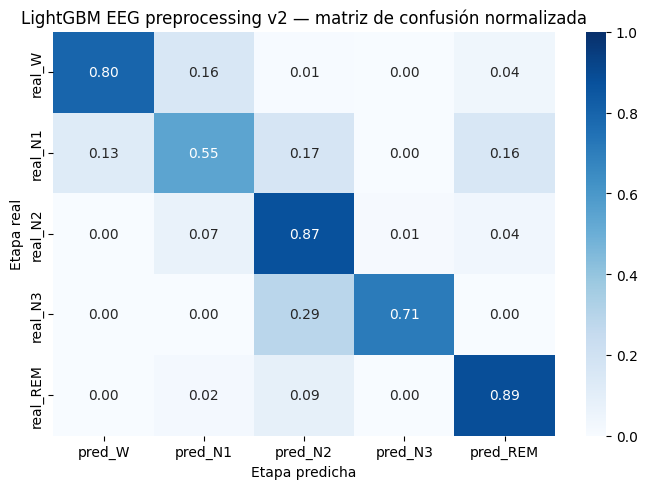

,f1_N1,f1_macro,delta_f1_N1,delta_f1_macro
baseline EEG v1,0.512574,0.763961,0.000000,0.0000
EEG preprocessing v2,0.511678,0.769562,-0.000895,0.0056


In [6]:
display_evaluation(lgbm_evaluation_v2)

baseline = pd.Series(
    {'f1_N1': 0.512573569, 'f1_macro': 0.763961492},
    name='baseline EEG v1',
)
current = pd.Series(
    {
        'f1_N1': float(lgbm_evaluation_v2.per_class.loc['N1', 'f1-score']),
        'f1_macro': lgbm_evaluation_v2.metrics['f1_macro'],
    },
    name='EEG preprocessing v2',
)
comparison = pd.concat([baseline, current], axis=1).T
comparison['delta_f1_N1'] = comparison['f1_N1'] - baseline['f1_N1']
comparison['delta_f1_macro'] = comparison['f1_macro'] - baseline['f1_macro']
display(comparison.round(6))

## Nota metodológica

Este notebook permite una comparación directa con el baseline histórico, pero la decisión final debe confirmarse mediante validación agrupada por sujeto. El holdout actual ya fue consultado durante la búsqueda de hiperparámetros.

## 7. Búsqueda de hiperparámetros sobre el preprocesamiento v2

Se reprodujeron cuatro configuraciones históricas únicas y se hicieron tres aproximaciones adaptativas. La selección prioriza `f1_N1` y usa `f1_macro` como métrica secundaria.

In [7]:
search_results = pd.DataFrame([
    {'candidate': 'H1 leaves=32', 'learning_rate': 0.025, 'n_estimators': 800, 'num_leaves': 32, 'skip_drop': 0.50, 'N1_weight': 2.20, 'f1_N1': 0.505183, 'f1_macro': 0.767919},
    {'candidate': 'H2 skip=0.65', 'learning_rate': 0.025, 'n_estimators': 800, 'num_leaves': 36, 'skip_drop': 0.65, 'N1_weight': 2.20, 'f1_N1': 0.504545, 'f1_macro': 0.766040},
    {'candidate': 'H3 winner', 'learning_rate': 0.030, 'n_estimators': 667, 'num_leaves': 36, 'skip_drop': 0.50, 'N1_weight': 2.20, 'f1_N1': 0.511678, 'f1_macro': 0.769562},
    {'candidate': 'H4 trees=1000', 'learning_rate': 0.025, 'n_estimators': 1000, 'num_leaves': 36, 'skip_drop': 0.50, 'N1_weight': 2.20, 'f1_N1': 0.504164, 'f1_macro': 0.766341},
    {'candidate': 'A1 lr=.032', 'learning_rate': 0.032, 'n_estimators': 625, 'num_leaves': 36, 'skip_drop': 0.50, 'N1_weight': 2.20, 'f1_N1': 0.506857, 'f1_macro': 0.768266},
    {'candidate': 'A2 lr=.029', 'learning_rate': 0.029, 'n_estimators': 690, 'num_leaves': 36, 'skip_drop': 0.50, 'N1_weight': 2.20, 'f1_N1': 0.510569, 'f1_macro': 0.768760},
    {'candidate': 'A3 N1w=2.15', 'learning_rate': 0.030, 'n_estimators': 667, 'num_leaves': 36, 'skip_drop': 0.50, 'N1_weight': 2.15, 'f1_N1': 0.510383, 'f1_macro': 0.767870},
]).sort_values(['f1_N1', 'f1_macro'], ascending=False)
display(search_results.reset_index(drop=True))
print('Ganador:', LGBM_PARAMS)

,candidate,learning_rate,n_estimators,num_leaves,skip_drop,N1_weight,f1_N1,f1_macro
0,H3 winner,0.030,667,36,0.50,2.20,0.511678,0.769562
1,A2 lr=.029,0.029,690,36,0.50,2.20,0.510569,0.768760
2,A3 N1w=2.15,0.030,667,36,0.50,2.15,0.510383,0.767870
3,A1 lr=.032,0.032,625,36,0.50,2.20,0.506857,0.768266
4,H1 leaves=32,0.025,800,32,0.50,2.20,0.505183,0.767919
5,H2 skip=0.65,0.025,800,36,0.65,2.20,0.504545,0.766040
6,H4 trees=1000,0.025,1000,36,0.50,2.20,0.504164,0.766341


Ganador: {'boosting_type': 'dart', 'learning_rate': 0.03, 'min_child_samples': 25, 'n_estimators': 667, 'num_leaves': 36, 'max_depth': 8, 'drop_rate': 0.1, 'skip_drop': 0.5, 'reg_alpha': 0.1, 'reg_lambda': 1.5, 'class_weight': {'N1': 2.2, 'N2': 0.41, 'N3': 1.56, 'REM': 1.0, 'W': 2.01}}


## 8. Reentrenamiento final y exportación para DVC/API

Esta celda vuelve a entrenar el ganador con **todo el dataset**. Exporta el Booster nativo de LightGBM y un manifiesto que fija el orden de las features, las clases, el preprocesamiento y los hiperparámetros. El directorio `data/models/` está cubierto por `data.dvc`.

In [ ]:
from dataclasses import asdict
import json
import numpy as np
from lightgbm import Booster

FINAL_MODEL_DIR = REPO_ROOT / 'data' / 'models' / 'sleep_staging_lightgbm_eeg_v2'
FINAL_MODEL_DIR.mkdir(parents=True, exist_ok=True)

#LGBM Params winner
LGBM_PARAMS = {
    "boosting_type": "dart",
    "learning_rate": 0.03,
    "min_child_samples": 25,
    "n_estimators": 667,
    "num_leaves": 36,
    "max_depth": 8,
    "drop_rate": 0.10,
    "skip_drop": 0.50,
    "reg_alpha": 0.10,
    "reg_lambda": 1.50,
    "class_weight": {
        "N1": 2.20,
        "N2": 0.41,
        "N3": 1.56,
        "REM": 1.00,
        "W": 2.01,
    },
}


final_model = create_lightgbm_classifier(random_state=SEED, **LGBM_PARAMS)
final_model.fit(dataset.features, dataset.labels)

native_model_path = FINAL_MODEL_DIR / 'model.txt'
manifest_path = FINAL_MODEL_DIR / 'manifest.json'
final_model.booster_.save_model(str(native_model_path))

manifest = {
    'artifact_version': 1,
    'model_type': 'LightGBM Booster',
    'model_file': native_model_path.name,
    'classes': [str(label) for label in final_model.classes_],
    'feature_columns': list(dataset.features.columns),
    'preprocessing': asdict(PREPROCESSING),
    'parameters': LGBM_PARAMS,
    'training_epochs': len(dataset.features),
    'training_subjects': int(dataset.metadata.subject_id.nunique()),
    'holdout_metrics_before_full_retraining': {
        'f1_N1': float(lgbm_evaluation_v2.per_class.loc['N1', 'f1-score']),
        'f1_macro': float(lgbm_evaluation_v2.metrics['f1_macro']),
        'accuracy': float(lgbm_evaluation_v2.metrics['accuracy']),
    },
}
manifest_path.write_text(
    json.dumps(manifest, ensure_ascii=False, indent=2), encoding='utf-8'
)

# Ejemplo mínimo de carga para una API de inferencia.
loaded_manifest = json.loads(manifest_path.read_text(encoding='utf-8'))
config_payload = loaded_manifest['preprocessing'].copy()
for tuple_field in ('channels', 'rolling_windows', 'temporal_difference_offsets', 'temporal_difference_tokens'):
    config_payload[tuple_field] = tuple(config_payload[tuple_field])
api_pipeline = PreprocessingPipeline(PreprocessingConfig(**config_payload))
api_model = Booster(model_file=str(FINAL_MODEL_DIR / loaded_manifest['model_file']))

def predict_feature_frame(feature_frame: pd.DataFrame) -> pd.Series:
    expected = loaded_manifest['feature_columns']
    missing = sorted(set(expected) - set(feature_frame.columns))
    if missing:
        raise ValueError(f'Faltan {len(missing)} features; primeras: {missing[:5]}')
    probabilities = api_model.predict(feature_frame.loc[:, expected])
    labels = np.asarray(loaded_manifest['classes'])
    return pd.Series(labels[np.argmax(probabilities, axis=1)], index=feature_frame.index)

smoke_prediction = predict_feature_frame(dataset.features.iloc[:1])
print(f'Modelo guardado en: {native_model_path}')
print(f'Manifiesto guardado en: {manifest_path}')
print(f'Prueba de carga/predicción: {smoke_prediction.iloc[0]}')

Modelo guardado en: E:\PROJECTS\Maestria Inteligencia Artificial\masterIADesarollo\micro-proyecto-grupo-7\data\models\sleep_staging_lightgbm_eeg_v2\model.txt
Manifiesto guardado en: E:\PROJECTS\Maestria Inteligencia Artificial\masterIADesarollo\micro-proyecto-grupo-7\data\models\sleep_staging_lightgbm_eeg_v2\manifest.json
Prueba de carga/predicción: W
